In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [49]:
# ==========================================
# Helper Function: Varimax Rotation
# ==========================================
def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    """
    Perform Varimax (orthogonal) rotation on a loadings matrix.
    """
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for i in range(q):
        d_old = d
        Lambda = np.dot(Phi, R)
        u, s, vh = np.linalg.svd(
            np.dot(Phi.T, np.asarray(Lambda)**3 - (gamma/p) * np.dot(Lambda, np.diag(np.diag(np.dot(Lambda.T, Lambda)))))
        )
        R = np.dot(u, vh)
        d = np.sum(s)
        if d_old != 0 and d / d_old < 1 + tol: 
            break
    return np.dot(Phi, R)

In [50]:
# ==========================================
# 1. Load & Preprocess Data
# ==========================================
print("Loading data from application_train.csv...")
df = pd.read_csv('../dataset/application_train.csv')

# Drop the TARGET variable so it doesn't leak into our PCA
if 'TARGET' in df.columns:
    df = df.drop(columns=['TARGET'])

# Select only numeric columns for this PCA
numeric_cols = df.select_dtypes(include=[np.number]).columns
X_numeric = df[numeric_cols]

print("Imputing missing values and scaling data...")
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_numeric)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

Loading data from application_train.csv...
Imputing missing values and scaling data...


In [51]:
# ==========================================
# 2. Perform PCA
# ==========================================
print("Fitting PCA model...")
pca = PCA()
pca.fit(X_scaled)

eigenvalues = pca.explained_variance_
eigenvectors = pca.components_.T  # Shape: (n_features, n_components)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

Fitting PCA model...


In [52]:
# ==========================================
# 2. Perform PCA
# ==========================================
print("Fitting PCA...")
pca = PCA()
pca.fit(X_scaled)

eigenvalues = pca.explained_variance_
eigenvectors = pca.components_.T  # Shape: (n_features, n_components)

Fitting PCA...


In [ ]:
# ==========================================
# 3. Print Output Matrices
# ==========================================
print("\n" + "="*50)
print(" EIGENVALUES (Top 10)")
print("="*50)
print(pd.Series(eigenvalues, index=[f'PC{i+1}' for i in range(len(eigenvalues))]).head(10))

print("\n" + "="*50)
print(" EIGENVECTORS (First 2 Components, Top 10 Features)")
print("="*50)
eigenvectors_df = pd.DataFrame(eigenvectors[:, :5], index=numeric_cols, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
print(eigenvectors_df.head(10))

# Rotate the top 5 components for interpretation
n_components_rotation = 5
unrotated_loadings = eigenvectors[:, :n_components_rotation] * np.sqrt(eigenvalues[:n_components_rotation])
unrotated_df = pd.DataFrame(unrotated_loadings, index=numeric_cols, columns=[f'PC{i+1}' for i in range(n_components_rotation)])

print("\n" + "="*50)
print(" LOADING MATRIX: BEFORE ROTATION (Unrotated)")
print("="*50)
print(unrotated_df.head(10))

rotated_loadings = varimax(unrotated_loadings)
rotated_df = pd.DataFrame(rotated_loadings, index=numeric_cols, columns=[f'RC{i+1}' for i in range(n_components_rotation)])

print("\n" + "="*50)
print(" LOADING MATRIX: AFTER VARIMAX ROTATION (Rotated)")
print("="*50)
print(rotated_df.head(10))


 EIGENVALUES (Top 10)
PC1     18.236197
PC2      4.820974
PC3      4.137877
PC4      3.438598
PC5      3.083232
PC6      2.910546
PC7      2.574198
PC8      2.520818
PC9      2.491177
PC10     2.295709
dtype: float64

 EIGENVECTORS (First 2 Components, Top 10 Features)


ValueError: Shape of passed values is (105, 10), indices imply (105, 2)


Generating Plots...


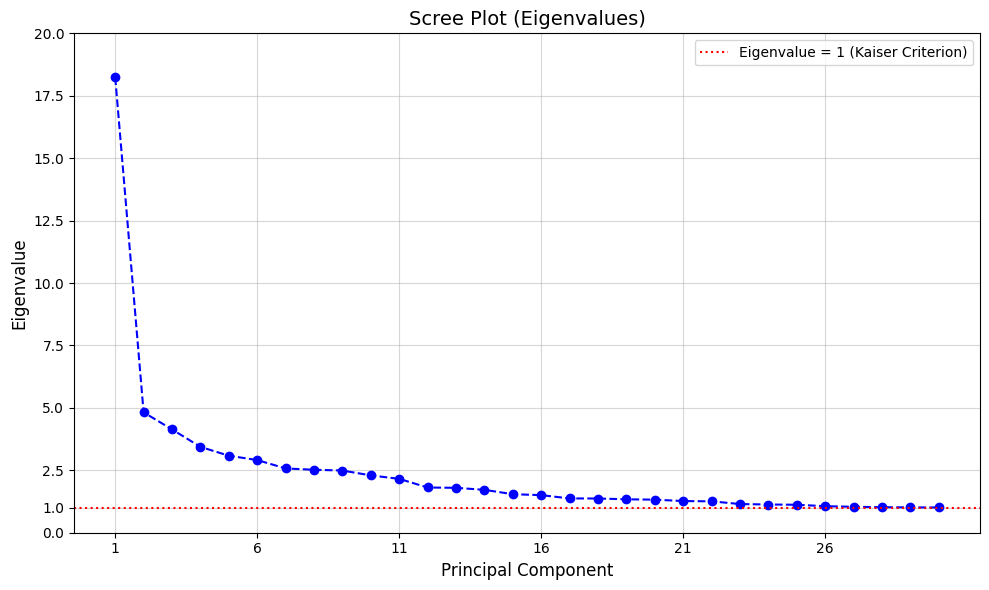

In [54]:
# ==========================================
# 4. Data Visualizations
# ==========================================
print("\nGenerating Plots...")

# --- Plot A: Scree Plot (Eigenvalues / Elbow Method) ---
plt.figure(figsize=(10, 6))
num_components_to_plot = min(30, len(eigenvalues))

plt.plot(
    range(1, num_components_to_plot + 1),
    eigenvalues[:num_components_to_plot],
    marker="o",
    linestyle="--",
    color="blue"
)

# 1. Add a horizontal line at y=1 (Kaiser Criterion)
plt.axhline(y=1, color='r', linestyle=':', label='Eigenvalue = 1 (Kaiser Criterion)')

# 2. Force the y-axis to include 1 and show it as a tick
current_yticks = plt.yticks()[0]
plt.yticks(list(current_yticks) + [1]) 

# Keep the x-axis starting at 1
plt.xticks(range(1, num_components_to_plot + 1, 5))

plt.title("Scree Plot (Eigenvalues)", fontsize=14)
plt.xlabel("Principal Component", fontsize=12)
plt.ylabel("Eigenvalue", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

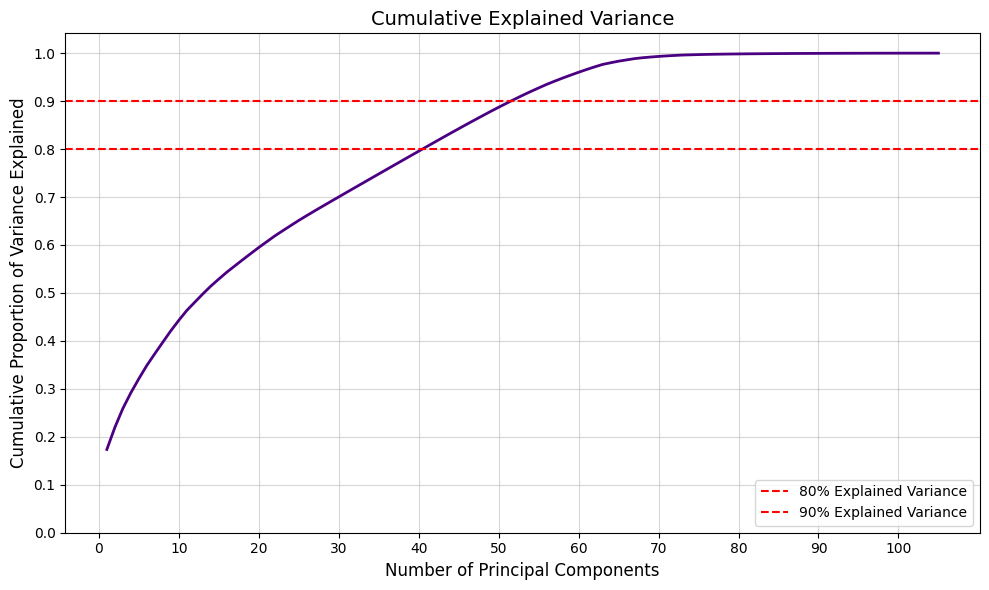

In [55]:
# --- Plot B: Cumulative Explained Variance ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linestyle='-', color='indigo', linewidth=2)

# Red dashed lines for 80% and 90% variance thresholds
plt.axhline(y=0.80, color='r', linestyle='--', linewidth=1.5, label='80% Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='--', linewidth=1.5, label='90% Explained Variance')

# Improve y-axis ticks to clearly show the thresholds
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(range(0, len(cumulative_variance) + 1, 10))

plt.title('Cumulative Explained Variance', fontsize=14)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Proportion of Variance Explained', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

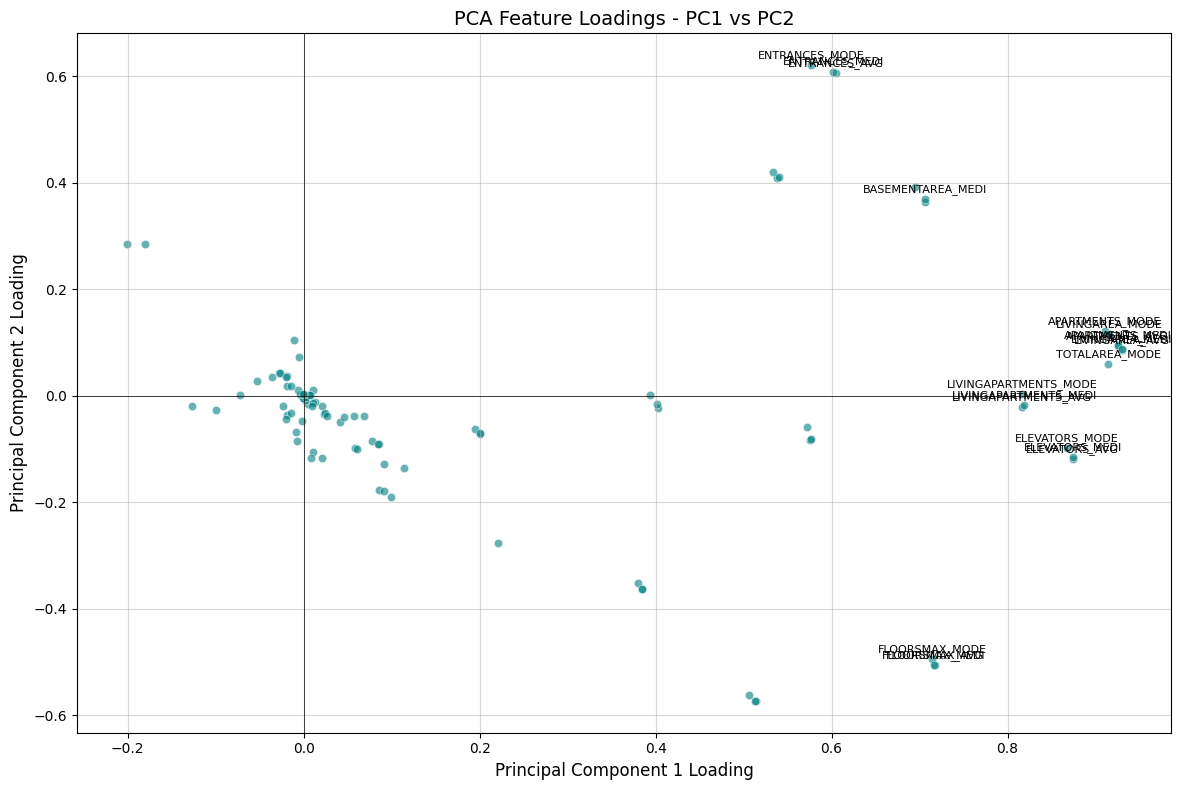

In [56]:
# --- Plot C: PCA Loadings (Rotation) Plot for PC1 vs PC2 ---
plt.figure(figsize=(12, 8))
sns.scatterplot(x=unrotated_df['PC1'], y=unrotated_df['PC2'], alpha=0.6, color='teal')
plt.title('PCA Feature Loadings - PC1 vs PC2', fontsize=14)
plt.xlabel('Principal Component 1 Loading', fontsize=12)
plt.ylabel('Principal Component 2 Loading', fontsize=12)

# Annotate the top 20 features driving the variance
unrotated_df['magnitude'] = np.sqrt(unrotated_df['PC1']**2 + unrotated_df['PC2']**2)
top_features = unrotated_df.nlargest(20, 'magnitude')

for feature in top_features.index:
    plt.annotate(feature, 
                 (unrotated_df.loc[feature, 'PC1'], unrotated_df.loc[feature, 'PC2']),
                 textcoords="offset points", 
                 xytext=(0, 5), 
                 ha='center', 
                 fontsize=8)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()